<a href="https://colab.research.google.com/github/tejasrisirisha/Data-Analysis-Projects/blob/main/Customer%20Purchase%20Prediction(1/8/26)%20/Customer_Purchase_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("/content/Shopping Mall Customer Segmentation Data .csv")

In [5]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB


In [7]:
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


In [8]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Annual Income,0
Spending Score,0


In [9]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

In [13]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Annual Income', 'Spending Score'], dtype='object')

In [14]:
df[['Customer ID', 'Age']].corr()

,Customer ID,Age
Customer ID,1.000000,-0.007636
Age,-0.007636,1.000000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

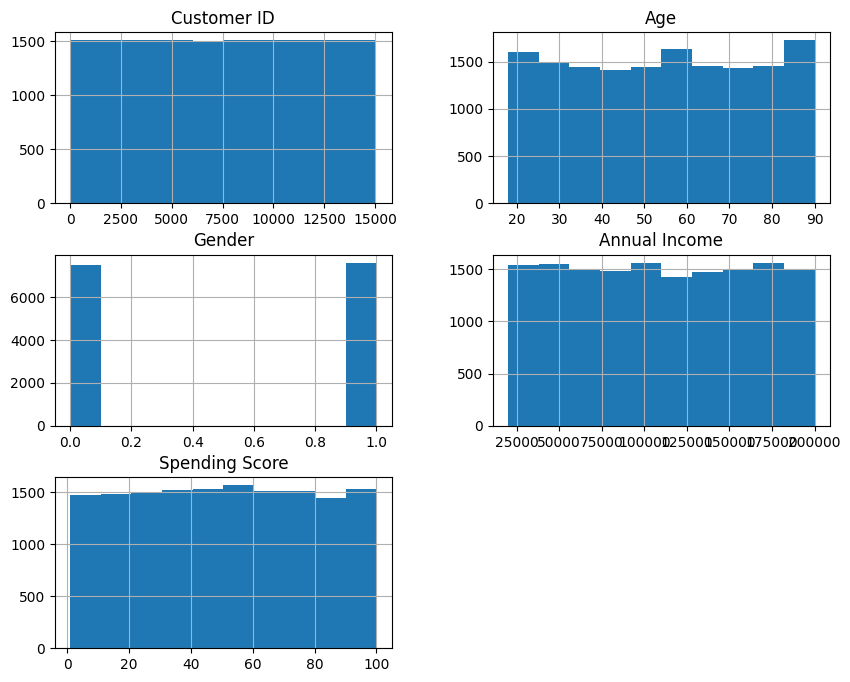

In [16]:
df.hist(figsize=(10,8))

plt.show()

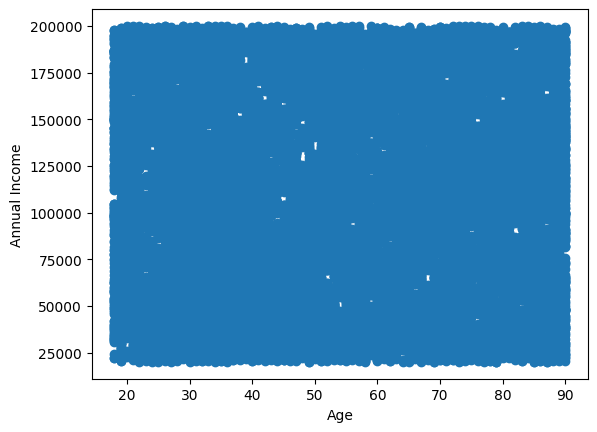

In [19]:
plt.scatter(df["Age"], df["Annual Income"])

plt.xlabel("Age")

plt.ylabel("Annual Income")

plt.show()

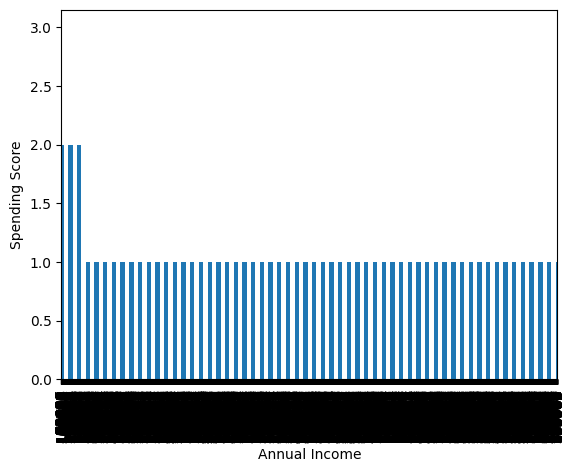

In [20]:
df["Annual Income"].value_counts().plot(kind="bar")

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.show()

In [21]:
X = df.drop("Spending Score", axis=1)

y = df["Spending Score"]

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [29]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [33]:
def evaluate(y_test, y_pred):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
    print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

In [34]:
import warnings
warnings.filterwarnings("ignore")

In [35]:
print("Logistic Regression")

evaluate(y_test, y_pred_lr)

Logistic Regression
Accuracy : 0.011273209549071617
Precision: 0.002595337233426049
Recall   : 0.011273209549071617
F1 Score : 0.003660235362909651


In [36]:
print("KNN")

evaluate(y_test, y_pred_knn)

KNN
Accuracy : 0.009283819628647215
Precision: 0.006805503773131543
Recall   : 0.009283819628647215
F1 Score : 0.006742318658748501


In [37]:
print("Decision Tree")

evaluate(y_test, y_pred_dt)

Decision Tree
Accuracy : 0.011273209549071617
Precision: 0.011384101967243676
Recall   : 0.011273209549071617
F1 Score : 0.011181914582045047


In [39]:
print(df["Annual Income"].value_counts())

Annual Income
38434     3
73406     3
178726    3
153857    3
167612    3
         ..
83428     1
26895     1
104682    1
171972    1
154418    1
Name: count, Length: 14441, dtype: int64


In [40]:
import joblib
bestmodel=dt
joblib.dump(bestmodel,"bestmodel.pkl")
print("best model saved succesfully")

best model saved succesfully


In [41]:
predictions = bestmodel.predict(X_test)

print(predictions)

[ 38 100  54 ...  50  47  90]
